In [3]:
import requests
import json
from datetime import datetime, timedelta, timezone
from datetime import timezone
import time
import random
import asyncio, aiohttp
import matplotlib.pyplot as plt
from collections import defaultdict

_TOKEN_CACHE = None  # global cache

def get_session_token():
    global _TOKEN_CACHE
    if _TOKEN_CACHE:   # reuse valid token
        return _TOKEN_CACHE

    url = "https://bsky.social/xrpc/com.atproto.server.createSession"
    handle = "repostproj.bsky.social"
    app_password = "vyvc-xg5q-seda-utaz" 

    for _ in range(3):  # retry a few times on rate limit
        r = requests.post(url, json={"identifier": handle, "password": app_password})
        if r.status_code == 429:
            print("⚠️ Rate-limited on login, sleeping 5s...")
            time.sleep(1)
            continue
        r.raise_for_status()
        _TOKEN_CACHE = r.json()["accessJwt"]
        return _TOKEN_CACHE

    raise RuntimeError("Failed to obtain token after retries")


In [4]:



def fmt(dt):
    """Convert datetime → Bluesky timestamp format."""
    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=timezone.utc)
    return dt.strftime("%Y-%m-%dT%H:%M:%S.000Z")


def parse_dt(created):
    """Parse Bluesky createdAt → naive UTC datetime."""
    return (
        datetime.fromisoformat(created.replace("Z", "+00:00"))
        .astimezone(timezone.utc)
        .replace(tzinfo=None)
    )


def fetch_posts(
    query,
    since_dt,
    until_dt,
    outfile,
    max_posts=None
):
    """
    Fetch ALL posts the Bluesky index returns between since_dt and until_dt.
    Continues by stepping `until` backward using the oldest timestamp.

    """

    url = "https://bsky.social/xrpc/app.bsky.feed.searchPosts"
    token = get_session_token()

    headers = {"Authorization": f"Bearer {token}"}

    current_until = until_dt
    total = 0
    last_print = 0

    with open(outfile, "w", encoding="utf-8") as f:

        while True:

            params = {
                "q": query,
                "limit": 100,
                "sort": "latest",
                "since": fmt(since_dt),
                "until": fmt(current_until),
            }

            r = requests.get(url, headers=headers, params=params)

            if r.status_code in (429, 502):
                time.sleep(1)
                continue

            if r.status_code != 200:
                break

            data = r.json()
            posts = data.get("posts", [])

            if not posts:
                break

            # write posts
            for p in posts:
                f.write(json.dumps(p, ensure_ascii=False) + "\n")
                total += 1

                if total - last_print >= 2000:
                    print(f"\rCollected {total} posts so far…", end="", flush=True)
                    last_print = total

                if max_posts and total >= max_posts:
                    return total

            # move backward in time
            oldest_ts = posts[-1]["record"]["createdAt"]
            oldest_dt = parse_dt(oldest_ts)

            if oldest_dt <= since_dt:
                return total

            current_until = oldest_dt

    return total


In [7]:
file = 'sports.jsonl'


In [8]:

fetch_posts(
    query="#sports",
    since_dt=datetime(2026, 1, 1),
    until_dt=datetime(2026, 1, 26),
    outfile=file,
    max_posts=100
)

100

In [11]:

def count_tagged_posts(tag, file_path=file):
    """
    
    Args:
        file_path (str): Path to the JSONL file containing Bluesky post objects.
    
    Returns:
        int: Number of posts that have 'tag' as a tag.
    """
    count = 0

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                post = json.loads(line.strip())
                record = post.get('record', {})
                facets = record.get('facets', [])
                
                # Extract tags from facets
                tags = []
                for facet in facets:
                    for feature in facet.get('features', []):
                        if feature.get('$type') == 'app.bsky.richtext.facet#tag':
                            tags.append(feature.get('tag', '').lower())

                if tag.lower() in tags:
                    count += 1

            except json.JSONDecodeError:
                continue  # skip malformed l
        return count

print(count_tagged_posts("Minneapolis"))


18931


In [12]:


def get_post_day_stats(file_path=file):
    stats = defaultdict(lambda: {
        "count": 0,
        "min_hour": None,
        "max_hour": None
    })

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                p = json.loads(line)
            except json.JSONDecodeError:
                continue

            created = (p.get("record") or {}).get("createdAt")
            if not created:
                continue

            # Parse timestamp safely
            try:
                dt = datetime.fromisoformat(created.replace("Z", "+00:00"))
            except Exception:
                try:
                    dt = datetime.fromisoformat(created[:19])
                except:
                    continue

            day = dt.date().isoformat()
            hour = dt.hour

            # Update count
            stats[day]["count"] += 1

            # Update earliest hour
            if stats[day]["min_hour"] is None or hour < stats[day]["min_hour"]:
                stats[day]["min_hour"] = hour

            # Update latest hour
            if stats[day]["max_hour"] is None or hour > stats[day]["max_hour"]:
                stats[day]["max_hour"] = hour

    # Sort results by day
    return dict(sorted(stats.items()))


get_post_day_stats()

{'2026-01-01': {'count': 20, 'min_hour': 3, 'max_hour': 23},
 '2026-01-02': {'count': 9, 'min_hour': 2, 'max_hour': 21},
 '2026-01-03': {'count': 14, 'min_hour': 0, 'max_hour': 20},
 '2026-01-04': {'count': 13, 'min_hour': 0, 'max_hour': 23},
 '2026-01-05': {'count': 36, 'min_hour': 2, 'max_hour': 23},
 '2026-01-06': {'count': 29, 'min_hour': 0, 'max_hour': 22},
 '2026-01-07': {'count': 1276, 'min_hour': 0, 'max_hour': 23},
 '2026-01-08': {'count': 2296, 'min_hour': 0, 'max_hour': 23},
 '2026-01-09': {'count': 1140, 'min_hour': 0, 'max_hour': 23},
 '2026-01-10': {'count': 955, 'min_hour': 0, 'max_hour': 23},
 '2026-01-11': {'count': 555, 'min_hour': 0, 'max_hour': 23},
 '2026-01-12': {'count': 564, 'min_hour': 0, 'max_hour': 23},
 '2026-01-13': {'count': 479, 'min_hour': 0, 'max_hour': 23},
 '2026-01-14': {'count': 539, 'min_hour': 0, 'max_hour': 23},
 '2026-01-15': {'count': 967, 'min_hour': 0, 'max_hour': 23},
 '2026-01-16': {'count': 621, 'min_hour': 0, 'max_hour': 23},
 '2026-01-17

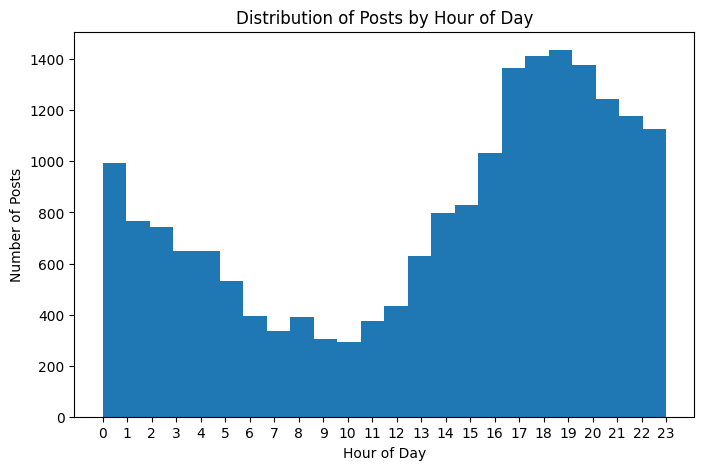

In [13]:



def plot_posts_by_hour(file_path):
    """
    Reads a .jsonl file of Bluesky posts and plots:
        Number of posts  vs  Hour of the day (0–23)
    """
    hours = []

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                post = json.loads(line)
            except json.JSONDecodeError:
                continue

            created = (post.get("record") or {}).get("createdAt")
            if not created:
                continue

            # Parse timestamp safely
            try:
                dt = datetime.fromisoformat(created.replace("Z", "+00:00"))
            except:
                try:
                    dt = datetime.fromisoformat(created[:19])
                except:
                    continue

            hours.append(dt.hour)

    # Plot
    plt.figure(figsize=(8,5))
    plt.hist(hours, bins=24)
    plt.xlabel("Hour of Day")
    plt.ylabel("Number of Posts")
    plt.title("Distribution of Posts by Hour of Day")
    plt.xticks(range(24))
    plt.show()

plot_posts_by_hour(file)


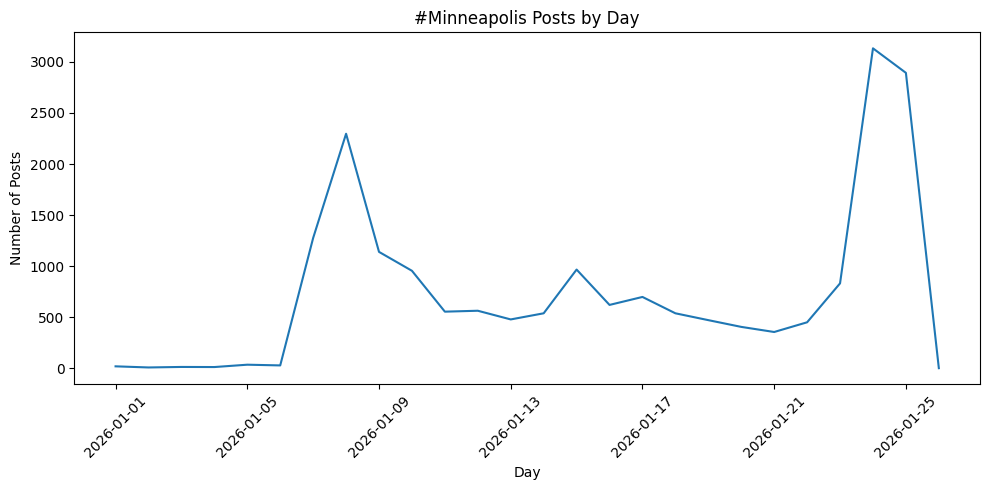

In [17]:

from collections import Counter


def plot_posts_by_day(file_path):
    """
    Reads a .jsonl file of Bluesky posts and plots:
        Number of posts vs Day
    """
    dates = []

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                post = json.loads(line)
            except json.JSONDecodeError:
                continue

            created = (post.get("record") or {}).get("createdAt")
            if not created:
                continue

            # Parse timestamp safely
            try:
                dt = datetime.fromisoformat(created.replace("Z", "+00:00"))
            except:
                try:
                    dt = datetime.fromisoformat(created[:19])
                except:
                    continue

            dates.append(dt.date())

    # Count posts per day
    counts = Counter(dates)
    days = sorted(counts.keys())
    values = [counts[d] for d in days]

    # Plot
    plt.figure(figsize=(10,5))
    plt.plot(days, values)
    plt.xlabel("Day")
    plt.ylabel("Number of Posts")
    plt.title("#Minneapolis Posts by Day")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_posts_by_day(file)
